## MNIST Classification using CNN with keras

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

In [19]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [20]:
## Print sample data
print("x_train shape:", x_train.shape)

x_train shape: (60000, 28, 28)


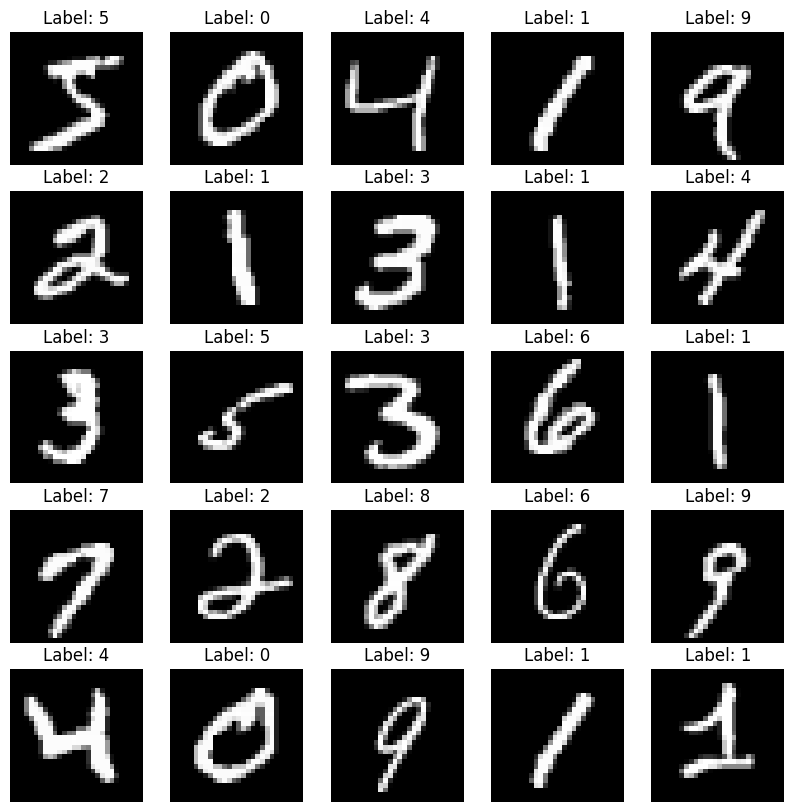

In [21]:
## Show sample images
plt.figure(figsize=(10, 10))
for i in range(25):
    k = i + 1
    plt.subplot(5, 5, k)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

In [ ]:
import keras
from keras.datasets import mnist
from keras.utils import to_categorical

# Reload data to ensure clean state
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

## Reshape and normalize the data
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255 #-1 automatically infers the number of samples
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255

# Check the shape of labels before one-hot encoding
print("Original y_train shape:", y_train.shape)
print("Sample labels:", y_train[:5])

##One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("After one-hot encoding y_train shape:", y_train.shape)
print("After one-hot encoding y_test shape:", y_test.shape)

Original y_train shape: (60000,)
Sample labels: [5 0 4 1 9]
After one-hot encoding y_train shape: (60000, 10)
After one-hot encoding y_test shape: (10000, 10)


## Step 2 : Build the CNN Model with keras Sequential API

In [23]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [24]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.8047 - loss: 0.6196 - val_accuracy: 0.9802 - val_loss: 0.0608
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.8047 - loss: 0.6196 - val_accuracy: 0.9802 - val_loss: 0.0608
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9710 - loss: 0.1031 - val_accuracy: 0.9850 - val_loss: 0.0446
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9710 - loss: 0.1031 - val_accuracy: 0.9850 - val_loss: 0.0446
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9788 - loss: 0.0729 - val_accuracy: 0.9893 - val_loss: 0.0327
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9788 - loss: 0.0729 - val_accuracy: 0.9893 - val_loss: 0.0327
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.9830 - loss: 0.0562 - val_accuracy: 0.9900 - val_loss: 0.0307
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.9830 - loss: 0.0562 - 

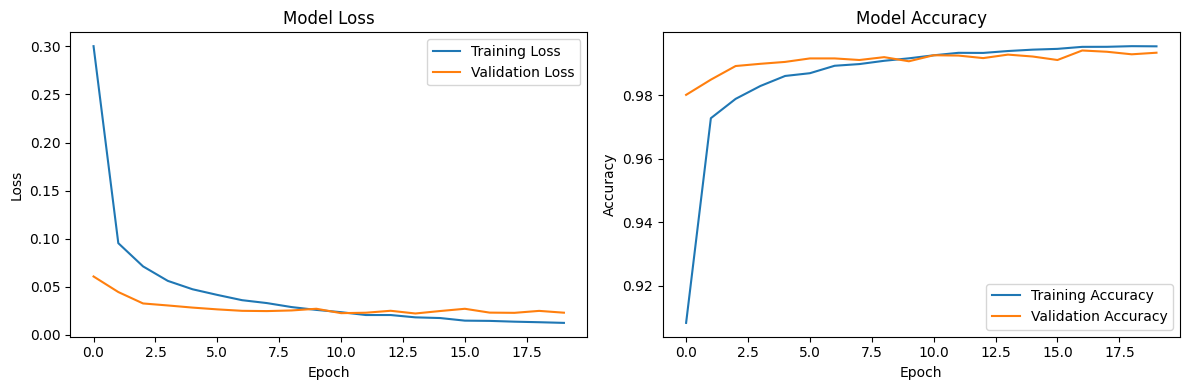

In [25]:
## Step 3. Compile the model

# Callback to print train/val loss and accuracy every 10 epochs
class PrintEvery10Epochs(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}: "
                  f"train_loss={logs['loss']:.4f}, "
                  f"val_loss={logs['val_loss']:.4f}, "
                  f"accuracy={logs['accuracy']:.4f}, "
                  f"val_accuracy={logs['val_accuracy']:.4f}")

callbacks = [PrintEvery10Epochs()]

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## Step 4. Train the model
history = model.fit(x_train, y_train, 
                   epochs=20, 
                   batch_size=128, 
                   validation_data=(x_test, y_test),
                   callbacks=callbacks)

## Step 5. Evaluate the model
# Plot training and validation loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Test Loss: 0.0231
Test Accuracy: 0.9935
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


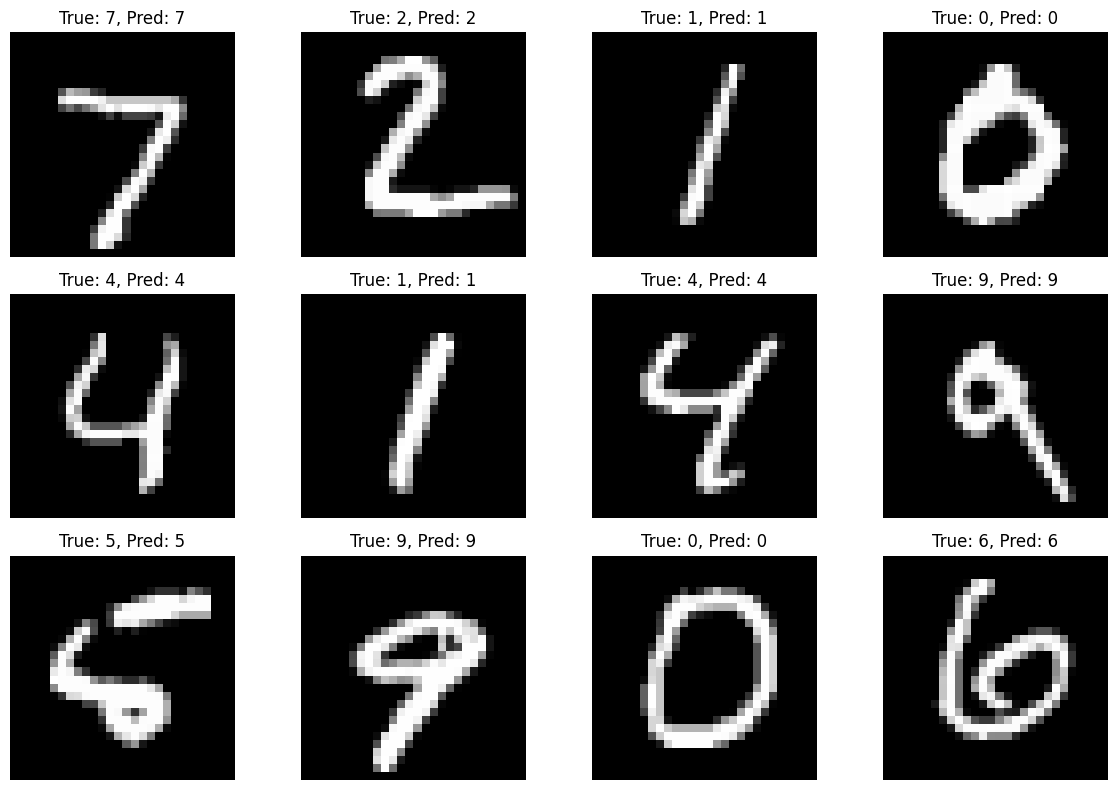

In [26]:
## Step 6. Final Evaluation
# Evaluate the model on test set
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Make predictions on test set
predictions = model.predict(x_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

# Show some sample predictions
plt.figure(figsize=(12, 8))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {true_classes[i]}, Pred: {predicted_classes[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

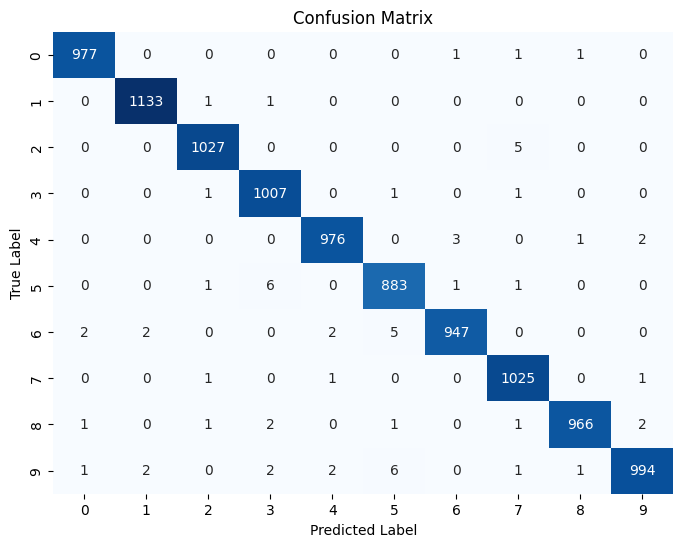

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [28]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(true_classes, predicted_classes, digits=4)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

           0     0.9959    0.9969    0.9964       980
           1     0.9965    0.9982    0.9974      1135
           2     0.9952    0.9952    0.9952      1032
           3     0.9892    0.9970    0.9931      1010
           4     0.9949    0.9939    0.9944       982
           5     0.9855    0.9899    0.9877       892
           6     0.9947    0.9885    0.9916       958
           7     0.9903    0.9971    0.9937      1028
           8     0.9969    0.9918    0.9943       974
           9     0.9950    0.9851    0.9900      1009

    accuracy                         0.9935     10000
   macro avg     0.9934    0.9934    0.9934     10000
weighted avg     0.9935    0.9935    0.9935     10000

